In [20]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
import io
import tempfile
import zipfile

import geopandas as gpd
import pandas as pd
import ocha_stratus as stratus
from dotenv import load_dotenv
import matplotlib.pyplot as plt

from src.datasources import grrr, nihsa

load_dotenv()

True

## Load data

In [22]:
gdf_lga_sel = stratus.load_geoparquet_from_blob(
    "ds-aa-nga-flooding/processed/selected_lgas_borno.parquet"
)

In [23]:
label_lgas = ["Ngala", "Monguno", "Kala/Balge", "Mafa", "Dikwa"]
gdf_focal = gdf_lga_sel[gdf_lga_sel["ADM2_EN"].isin(label_lgas)]

In [24]:
gdf_gauges = grrr.get_gauges_by_area(
    gdf_lga_sel,
    include_non_quality_verified=True
)
print(f"Total gauges in search area: {len(gdf_gauges)}")
print(f"  Quality-verified: {gdf_gauges.quality_verified.sum()}")

Total gauges in search area: 100
  Quality-verified: 1


In [25]:
gdf_codab = stratus.codab.load_codab_from_blob("NGA", admin_level=0)
gdf_lga = stratus.codab.load_codab_from_blob("NGA", admin_level=2)

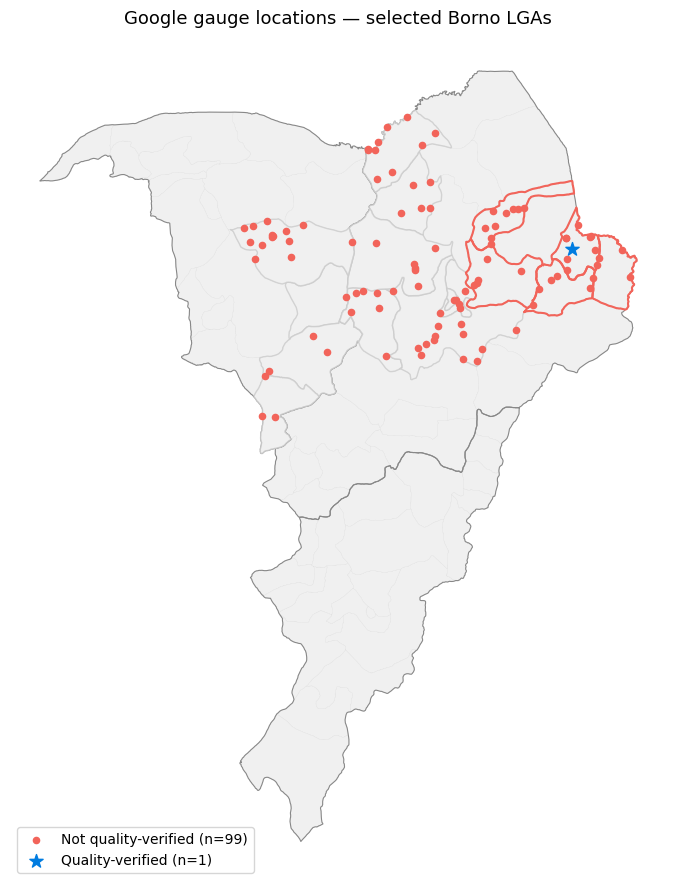

In [26]:
states = ["Borno", "Adamawa", "Yobe"]
gdf_lga_states = gdf_lga[gdf_lga["ADM1_EN"].isin(states)]
gdf_adm1_states = gdf_lga_states.dissolve(by="ADM1_EN").reset_index()

qv = gdf_gauges[gdf_gauges["quality_verified"]]
non_qv = gdf_gauges[~gdf_gauges["quality_verified"]]

fig, ax = plt.subplots(figsize=(10, 9))

gdf_lga_states.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#cccccc", linewidth=0.1)
gdf_adm1_states.plot(ax=ax, facecolor="none", edgecolor="#888888", linewidth=0.8)
gdf_lga_sel.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#cccccc", linewidth=1, alpha=0.8, zorder=3)
gdf_focal.plot(ax=ax, facecolor="none", edgecolor="#F2645A", linewidth=1.5, zorder=4)

non_qv.plot(ax=ax, color="#F2645A", markersize=20, zorder=5, label=f"Not quality-verified (n={len(non_qv)})")
qv.plot(ax=ax, color="#007CE0", markersize=100, marker="*", zorder=6, label=f"Quality-verified (n={len(qv)})")

ax.legend(fontsize=10, loc="lower left")
ax.set_title("Google gauge locations — selected Borno LGAs", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("figures/google_gauge_locations.png", dpi=300, bbox_inches="tight")

## Check model performance

How well does the reanalysis data from each Google gauge predict peaks in flooding from Floodscan?

In [27]:
df_floodscan = stratus.load_parquet_from_blob("ds-aa-nga-flooding/processed/floodscan/floodscan_hfr_lgas_borno.parquet")

In [28]:
# Load reanalysis streamflow for all gauges that have a model
gauges_with_model = gdf_gauges[gdf_gauges["has_model"] == True]
print(f"Loading reanalysis for {len(gauges_with_model)} gauges with models...")

gauge_ids = gauges_with_model["gauge_id"].tolist()
ds_ra = grrr.load_reanalysis(gauge=gauge_ids)
df_ra = grrr.process_reanalysis(ds_ra)
df_ra["date"] = pd.to_datetime(df_ra["valid_time"]).dt.normalize()

print(f"Reanalysis loaded: {df_ra['date'].min().date()} to {df_ra['date'].max().date()}")

# Assign each gauge to its nearest selected LGA
gdf_gauge_lga = gpd.sjoin_nearest(
    gauges_with_model[["gauge_id", "quality_verified", "geometry"]],
    gdf_lga_sel[["ADM2_PCODE", "ADM2_EN", "geometry"]],
    how="left",
).drop(columns=["index_right"])

print(gdf_gauge_lga[["gauge_id", "ADM2_EN", "quality_verified"]].to_string())

Loading reanalysis for 100 gauges with models...
Reanalysis loaded: 1980-01-01 to 2023-12-23
             gauge_id     ADM2_EN  quality_verified
8    hybas_1120694180      Mobbar             False
12   hybas_1120695690      Mobbar             False
15   hybas_1120696150      Mobbar             False
16   hybas_1120696160      Mobbar             False
22   hybas_1120703520      Mobbar             False
28   hybas_1120706790       Gubio             False
29   hybas_1120707780       Gubio             False
43   hybas_1120715640     Monguno             False
44   hybas_1120715850       Gubio             False
45   hybas_1120715860       Gubio             False
46   hybas_1120716060     Monguno             False
47   hybas_1120716200     Monguno             False
48   hybas_1120716590     Monguno             False
51   hybas_1120717360       Gubio             False
52   hybas_1120717370     Monguno             False
55   hybas_1120720130      Tarmua             False
59   hybas_1120721530  

/Users/hannahker/Desktop/AA/ds-aa-nga-flooding/venv/lib/python3.12/site-packages/geopandas/array.py:407: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


In [29]:
from scipy import stats as scipy_stats

# Prepare floodscan: daily SFED per LGA (keep all days for correct lag shifts)
df_fs_daily = df_floodscan.copy()
df_fs_daily["date"] = pd.to_datetime(df_fs_daily["valid_date"]).dt.normalize()

MAX_LAG = 14
MIN_LAG = -7
MIN_OBS = 60

def remove_seasonal(df, col, date_col="date"):
    """Subtract long-run day-of-year mean to get anomalies."""
    df = df.copy()
    df["doy"] = df[date_col].dt.dayofyear
    doy_mean = df.groupby("doy")[col].transform("mean")
    df[f"{col}_anom"] = df[col] - doy_mean
    return df

results = []

for _, gauge_row in gdf_gauge_lga.iterrows():
    gauge_id = gauge_row["gauge_id"]
    pcode = gauge_row["ADM2_PCODE"]
    lga_name = gauge_row["ADM2_EN"]
    qv = gauge_row["quality_verified"]

    df_sf = df_ra[df_ra["gauge_id"] == gauge_id][["date", "streamflow"]].copy()
    df_sfed = df_fs_daily[df_fs_daily["pcode"] == pcode][["date", "mean"]].copy()

    df_sf = remove_seasonal(df_sf, "streamflow")
    df_sfed = remove_seasonal(df_sfed, "mean")

    # Merge keeping all days to preserve calendar-day structure for shifts
    df_merged = df_sf.merge(df_sfed, on="date").dropna(subset=["streamflow_anom", "mean_anom"])
    if len(df_merged) < MIN_OBS:
        continue

    best_r, best_lag, best_p = 0.0, 0, 1.0
    lag_rs = {}
    for lag in range(MIN_LAG, MAX_LAG + 1):
        sfed_shifted = df_merged["mean_anom"].shift(-lag)
        sfed_raw_shifted = df_merged["mean"].shift(-lag)
        # Only correlate on days where the (shifted) SFED is non-zero
        valid = (
            df_merged["streamflow_anom"].notna()
            & sfed_shifted.notna()
            & (sfed_raw_shifted > 0)
        )
        if valid.sum() < MIN_OBS:
            continue
        r, p = scipy_stats.pearsonr(df_merged["streamflow_anom"][valid], sfed_shifted[valid])
        lag_rs[lag] = r
        if abs(r) > abs(best_r):
            best_r, best_lag, best_p = r, lag, p

    results.append({
        "gauge_id": gauge_id,
        "pcode": pcode,
        "lga_name": lga_name,
        "quality_verified": qv,
        "best_r": best_r,
        "best_lag_days": best_lag,
        "best_p": best_p,
        "lag_profile": lag_rs,
        "n_obs": len(df_merged),
    })

df_results = pd.DataFrame(results).sort_values("best_r", ascending=False).reset_index(drop=True)
print(f"Correlations computed for {len(df_results)} gauges")
df_results[["gauge_id", "lga_name", "quality_verified", "best_r", "best_lag_days", "best_p", "n_obs"]]

Correlations computed for 100 gauges


,gauge_id,lga_name,quality_verified,best_r,best_lag_days,best_p,n_obs
0,hybas_1120695690,Mobbar,False,0.523085,14,1.498367e-73,9477
1,hybas_1120696160,Mobbar,False,0.437613,14,1.608045e-49,9477
2,hybas_1121905650,Mobbar,False,0.435056,14,6.687526e-49,9477
3,hybas_1121930520,Kaga,False,0.423732,0,1.096636e-20,9477
4,hybas_1121928070,Kaga,False,0.418649,0,3.487831e-20,9477
...,...,...,...,...,...,...,...
95,hybas_1120706790,Gubio,False,-0.296785,-6,1.884046e-05,9477
96,hybas_1120707780,Gubio,False,-0.300056,-5,1.507160e-05,9477
97,hybas_1120715860,Gubio,False,-0.312368,-5,6.348489e-06,9477
98,hybas_1120715850,Gubio,False,-0.318957,-5,3.932760e-06,9477


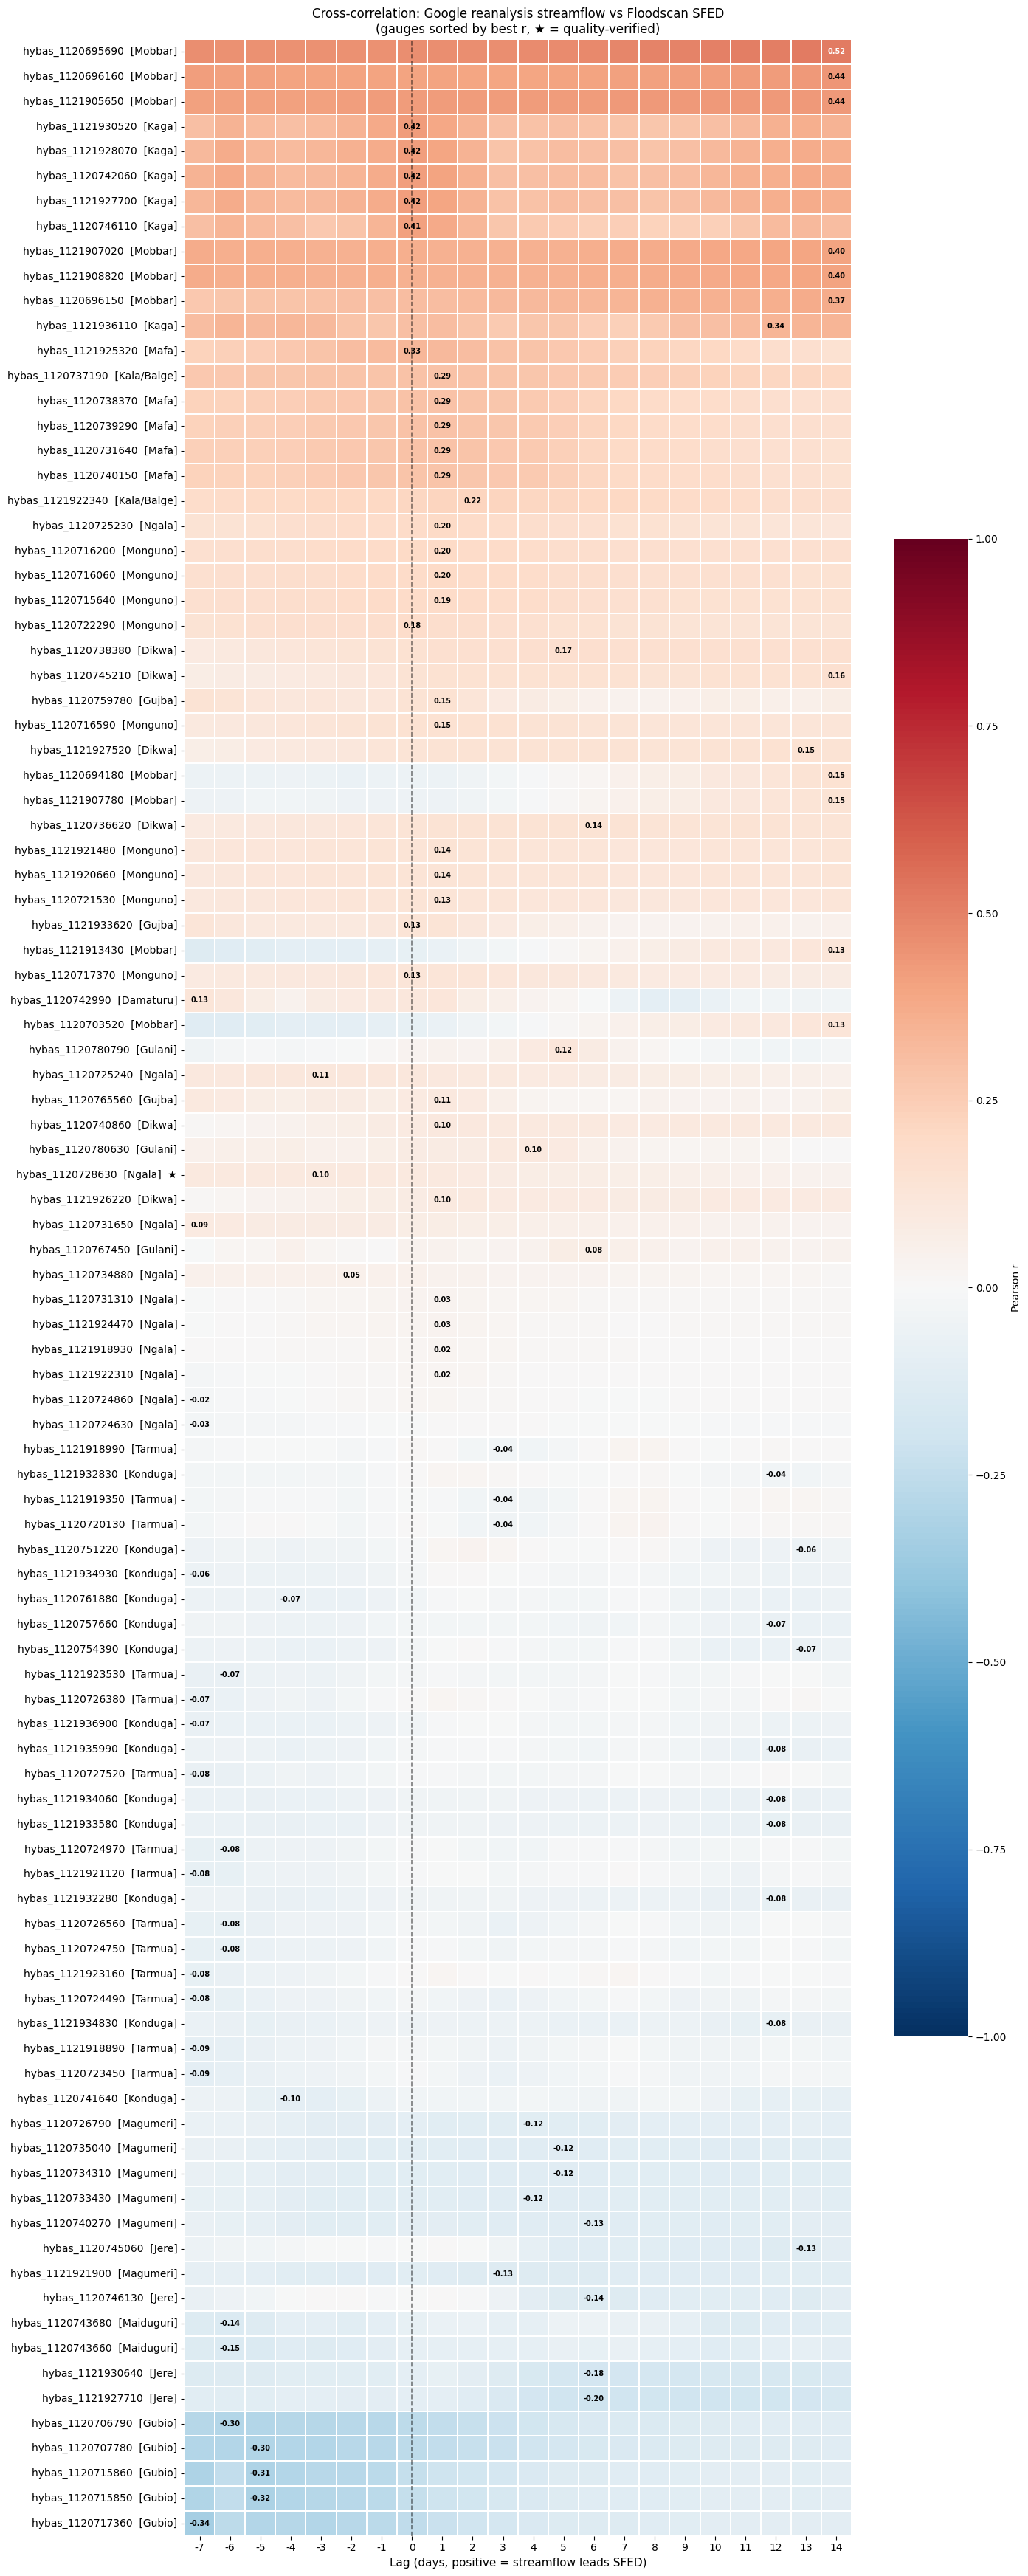

In [30]:
import seaborn as sns

# --- Lag-correlation heatmap: r at each lag, one row per gauge ---
lags = list(range(MIN_LAG, MAX_LAG + 1))

lag_matrix = pd.DataFrame(
    [row["lag_profile"] for _, row in df_results.iterrows()],
    index=df_results["gauge_id"],
    columns=lags,
)

row_labels = [
    f"{row['gauge_id']}  [{row['lga_name']}]{'  ★' if row['quality_verified'] else ''}"
    for _, row in df_results.iterrows()
]

fig, ax = plt.subplots(figsize=(14, max(4, len(df_results) * 0.35)))

sns.heatmap(
    lag_matrix,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    annot=False,
    linewidths=0.3,
    linecolor="white",
    yticklabels=row_labels,
    cbar_kws={"label": "Pearson r", "shrink": 0.6},
)

# Label the best-correlation cell per gauge
for row_idx, (_, row) in enumerate(df_results.iterrows()):
    best_lag = row["best_lag_days"]
    best_r = row["best_r"]
    if best_lag in lags:
        col_idx = lags.index(best_lag)
        ax.text(
            col_idx + 0.5, row_idx + 0.5,
            f"{best_r:.2f}",
            ha="center", va="center",
            fontsize=7, fontweight="bold",
            color="white" if abs(best_r) > 0.5 else "black",
        )

ax.set_xlabel("Lag (days, positive = streamflow leads SFED)", fontsize=11)
ax.set_ylabel("")
ax.set_title(
    "Cross-correlation: Google reanalysis streamflow vs Floodscan SFED\n(gauges sorted by best r, ★ = quality-verified)",
    fontsize=12,
)
ax.axvline(x=lags.index(0) + 0.5, color="black", linewidth=1.2, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("figures/gauge_sfed_lag_correlation.png", dpi=200, bbox_inches="tight")

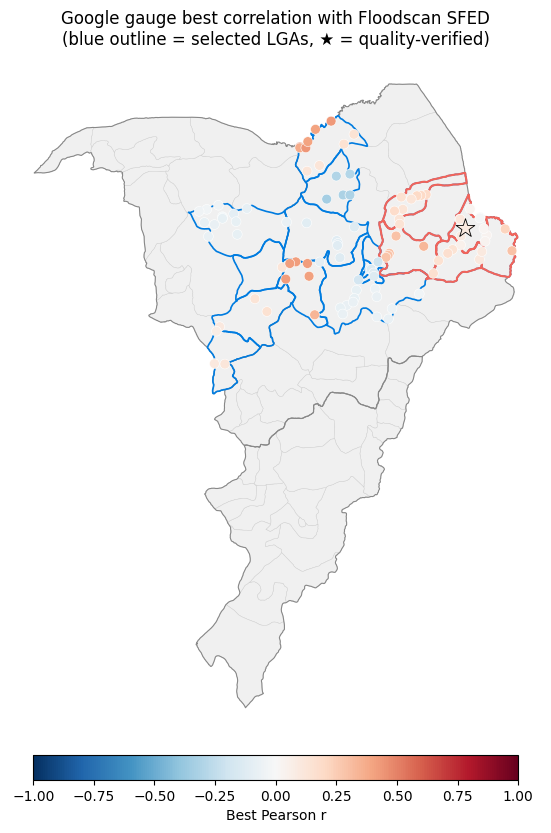

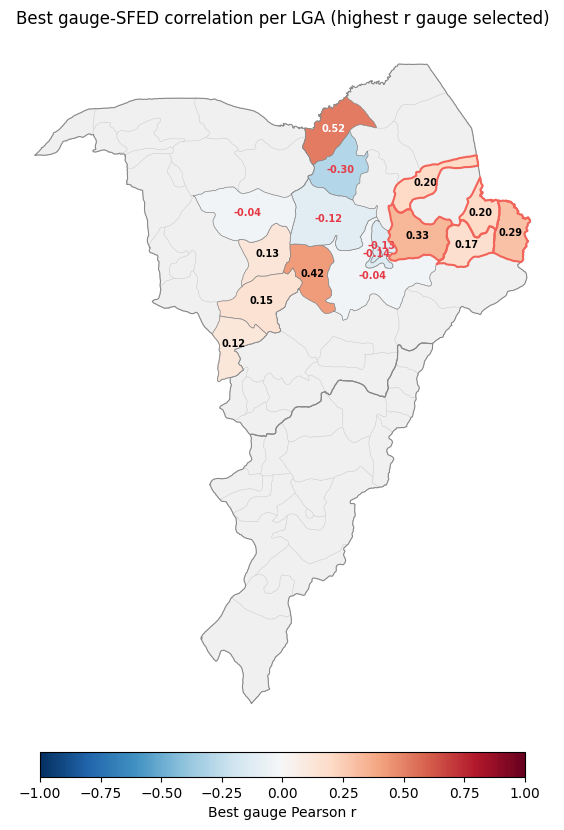

In [31]:
import matplotlib.colors as mcolors

# Merge best_r into gauge geodataframe
gdf_gauge_results = gauges_with_model.merge(
    df_results[["gauge_id", "best_r", "best_lag_days"]],
    on="gauge_id",
    how="inner",
)

norm = mcolors.Normalize(vmin=-1, vmax=1)
cmap = plt.cm.RdBu_r

# --- Map 1: gauges coloured by best correlation ---
fig, ax = plt.subplots(figsize=(10, 9))

gdf_lga_states.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#cccccc", linewidth=0.3)
gdf_adm1_states.plot(ax=ax, facecolor="none", edgecolor="#888888", linewidth=0.8)
gdf_lga_sel.plot(ax=ax, facecolor="none", edgecolor="#007CE0", linewidth=1.2, zorder=3)
gdf_focal.plot(ax=ax, facecolor="none", edgecolor="#F2645A", linewidth=1.5, zorder=4)

sc = ax.scatter(
    gdf_gauge_results.geometry.x,
    gdf_gauge_results.geometry.y,
    c=gdf_gauge_results["best_r"],
    cmap=cmap,
    norm=norm,
    s=50,
    zorder=5,
    edgecolors="white",
    linewidths=0.4,
)

qv_res = gdf_gauge_results[gdf_gauge_results["quality_verified"]]
ax.scatter(
    qv_res.geometry.x, qv_res.geometry.y,
    c=qv_res["best_r"], cmap=cmap, norm=norm,
    s=200, marker="*", zorder=6, edgecolors="black", linewidths=0.6,
)

plt.colorbar(sc, ax=ax, orientation="horizontal", shrink=0.5, pad=0.02, label="Best Pearson r")
ax.set_title("Google gauge best correlation with Floodscan SFED\n(blue outline = selected LGAs, ★ = quality-verified)", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("figures/gauge_best_r_map.png", dpi=200, bbox_inches="tight")

# --- Map 2: LGA choropleth — best gauge r per LGA ---
df_lga_best_r = (
    gdf_gauge_lga[["gauge_id", "ADM2_PCODE"]]
    .merge(df_results[["gauge_id", "best_r"]], on="gauge_id")
    .sort_values("best_r", ascending=False)
    .drop_duplicates("ADM2_PCODE")
    .rename(columns={"best_r": "best_gauge_r"})
)

gdf_lga_choropleth = gdf_lga_sel.merge(df_lga_best_r[["ADM2_PCODE", "best_gauge_r"]], on="ADM2_PCODE", how="left")

fig, ax = plt.subplots(figsize=(10, 9))

gdf_lga_states.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#cccccc", linewidth=0.3)
gdf_adm1_states.plot(ax=ax, facecolor="none", edgecolor="#888888", linewidth=0.8)

gdf_lga_choropleth.plot(
    ax=ax,
    column="best_gauge_r",
    cmap=cmap,
    norm=norm,
    edgecolor="#888888",
    linewidth=0.5,
    legend=True,
    legend_kwds={"label": "Best gauge Pearson r", "orientation": "horizontal", "shrink": 0.5, "pad": 0.02},
    missing_kwds={"color": "#cccccc", "edgecolor": "#888888", "label": "No gauges"},
    zorder=3,
)
gdf_focal.plot(ax=ax, facecolor="none", edgecolor="#F2645A", linewidth=1.5, zorder=4)

for _, row in gdf_lga_choropleth.iterrows():
    if pd.notna(row["best_gauge_r"]):
        centroid = row.geometry.centroid
        r = row["best_gauge_r"]
        color = "#E63946" if r < 0 else ("white" if r > 0.5 else "black")
        ax.text(
            centroid.x, centroid.y, f"{r:.2f}",
            ha="center", va="center", fontsize=7, fontweight="bold", color=color,
        )

ax.set_title("Best gauge-SFED correlation per LGA (highest r gauge selected)", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("figures/lga_best_r_choropleth.png", dpi=200, bbox_inches="tight")

## Return period comparison: Floodscan vs Google streamflow

Per LGA, compare annual return periods derived from Floodscan SFED peaks against return periods from the best-correlated Google gauge's streamflow peaks.

In [32]:
from src.utils import rp_calc

# --- Floodscan annual max + RP per LGA ---
df_fs = df_floodscan.copy()
df_fs["year"] = pd.to_datetime(df_fs["valid_date"]).dt.year
df_fs = df_fs[df_fs["year"] != 2026]

df_fs_valid = df_fs.groupby(["pcode", "year"]).filter(lambda x: x["mean"].notna().any())
df_fs_max = df_fs_valid.loc[
    df_fs_valid.groupby(["pcode", "year"])["mean"].idxmax()
][["pcode", "year", "mean"]]

df_fs_rp = rp_calc.calculate_groups_rp(df_fs_max, by=["pcode"], col_name="mean", ascending=False)
df_fs_rp = df_fs_rp.rename(columns={"mean_rp": "fs_rp", "mean": "fs_mean"})

# --- Streamflow annual max + RP per gauge ---
df_sf = df_ra.copy()
df_sf["year"] = pd.to_datetime(df_sf["valid_time"]).dt.year
df_sf = df_sf[df_sf["year"] != 2026]

df_sf_max = (
    df_sf.groupby(["gauge_id", "year"])["streamflow"]
    .max()
    .reset_index()
)
df_sf_rp = rp_calc.calculate_groups_rp(df_sf_max, by=["gauge_id"], col_name="streamflow", ascending=False)
df_sf_rp = df_sf_rp.rename(columns={"streamflow_rp": "sf_rp"})

# --- For each LGA, pick the best-correlated gauge ---
df_best_gauge = (
    df_results.sort_values("best_r", ascending=False)
    .drop_duplicates("pcode")[["pcode", "gauge_id", "lga_name", "best_r"]]
)

# Merge streamflow RP with best gauge assignment
df_sf_rp_lga = df_best_gauge.merge(df_sf_rp, on="gauge_id", how="inner")

# Merge with floodscan RP on pcode + year
df_rp_compare = df_fs_rp.merge(
    df_sf_rp_lga[["pcode", "lga_name", "gauge_id", "best_r", "year", "sf_rp"]],
    on=["pcode", "year"],
    how="inner",
).dropna(subset=["fs_rp", "sf_rp"])

print(f"LGAs with matched RP data: {df_rp_compare['pcode'].nunique()}")
print(f"Year range: {df_rp_compare['year'].min()}–{df_rp_compare['year'].max()}")
df_rp_compare.head()

LGAs with matched RP data: 16
Year range: 1998–2023


,pcode,year,fs_mean,mean_rank,fs_rp,lga_name,gauge_id,best_r,sf_rp
0,NG008008,1998,0.134399,3,9.666667,Dikwa,hybas_1120738380,0.166996,2.045455
1,NG008008,1999,0.062710,13,2.230769,Dikwa,hybas_1120738380,0.166996,9.000000
2,NG008008,2000,0.038130,18,1.611111,Dikwa,hybas_1120738380,0.166996,2.368421
3,NG008008,2001,0.058841,15,1.933333,Dikwa,hybas_1120738380,0.166996,2.250000
4,NG008008,2002,0.036328,19,1.526316,Dikwa,hybas_1120738380,0.166996,1.551724


Available pcodes:
    pcode   lga_name
NG008008      Dikwa
NG008009      Gubio
NG008013       Jere
NG008014       Kaga
NG008015 Kala/Balge
NG008016    Konduga
NG008019       Mafa
NG008020   Magumeri
NG008021  Maiduguri
NG008023     Mobbar
NG008024    Monguno
NG008025      Ngala
NG036003   Damaturu
NG036007      Gujba
NG036008     Gulani
NG036015     Tarmua


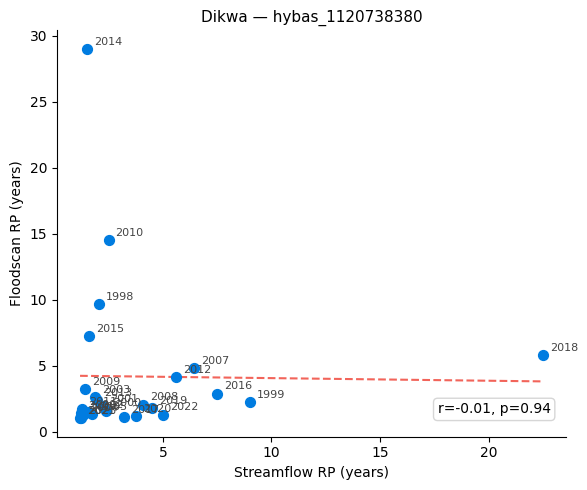

In [33]:
import numpy as np

PCODE = "NG008008"  # change to explore — see available pcodes below

available = df_rp_compare[["pcode", "lga_name"]].drop_duplicates()
print("Available pcodes:\n", available.to_string(index=False))

sub = df_rp_compare[df_rp_compare["pcode"] == PCODE]

if sub.empty:
    print(f"\n'{PCODE}' not found in df_rp_compare. Choose a pcode from the list above.")
else:
    lga_name = sub["lga_name"].iloc[0]
    gauge_id = sub["gauge_id"].iloc[0]

    fig, ax = plt.subplots(figsize=(6, 5))

    ax.scatter(sub["sf_rp"], sub["fs_rp"], color="#007CE0", s=50, zorder=3)

    for _, row in sub.iterrows():
        ax.annotate(str(int(row["year"])), (row["sf_rp"], row["fs_rp"]),
                    textcoords="offset points", xytext=(5, 3), fontsize=8, color="#444444")

    if len(sub) >= 3:
        m, b, r, p, _ = scipy_stats.linregress(sub["sf_rp"], sub["fs_rp"])
        x_line = np.linspace(sub["sf_rp"].min(), sub["sf_rp"].max(), 100)
        ax.plot(x_line, m * x_line + b, color="#F2645A", linewidth=1.5, linestyle="--")
        p_str = f"p={p:.2f}" if p >= 0.01 else "p<0.01"
        ax.text(0.97, 0.05, f"r={r:.2f}, {p_str}", transform=ax.transAxes,
                ha="right", va="bottom", fontsize=10,
                bbox=dict(boxstyle="round", facecolor="white", edgecolor="#cccccc", alpha=0.8))

    ax.set_title(f"{lga_name} — {gauge_id}", fontsize=11)
    ax.set_xlabel("Streamflow RP (years)", fontsize=10)
    ax.set_ylabel("Floodscan RP (years)", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()

In [34]:
# --- RP correlation per gauge (all 100 gauges vs nearest LGA Floodscan RP) ---
MIN_YEARS = 5  # minimum overlapping years to compute correlation

gauge_rp_results = []

for _, gauge_row in gdf_gauge_lga.iterrows():
    gauge_id = gauge_row["gauge_id"]
    pcode = gauge_row["ADM2_PCODE"]
    lga_name = gauge_row["ADM2_EN"]
    qv = gauge_row["quality_verified"]

    sf = df_sf_rp[df_sf_rp["gauge_id"] == gauge_id][["year", "sf_rp"]]
    fs = df_fs_rp[df_fs_rp["pcode"] == pcode][["year", "fs_rp"]]

    merged = sf.merge(fs, on="year").dropna()
    if len(merged) < MIN_YEARS:
        continue

    r, p = scipy_stats.pearsonr(merged["sf_rp"], merged["fs_rp"])
    gauge_rp_results.append({
        "gauge_id": gauge_id,
        "pcode": pcode,
        "lga_name": lga_name,
        "quality_verified": qv,
        "rp_r": r,
        "rp_p": p,
        "n_years": len(merged),
    })

df_gauge_rp = pd.DataFrame(gauge_rp_results).sort_values("rp_r", ascending=False).reset_index(drop=True)
print(f"Gauges with RP correlation: {len(df_gauge_rp)}")
df_gauge_rp.head(10)

Gauges with RP correlation: 100


,gauge_id,pcode,lga_name,quality_verified,rp_r,rp_p,n_years
0,hybas_1121933620,NG036007,Gujba,False,0.380853,0.054918,26
1,hybas_1120759780,NG036007,Gujba,False,0.354833,0.075287,26
2,hybas_1120731640,NG008019,Mafa,False,0.296223,0.141732,26
3,hybas_1121925320,NG008019,Mafa,False,0.289785,0.151011,26
4,hybas_1120742060,NG008014,Kaga,False,0.280433,0.165247,26
5,hybas_1120740150,NG008019,Mafa,False,0.230124,0.258073,26
6,hybas_1120739290,NG008019,Mafa,False,0.228940,0.260599,26
7,hybas_1120738370,NG008019,Mafa,False,0.220131,0.279888,26
8,hybas_1120765560,NG036007,Gujba,False,0.220051,0.280066,26
9,hybas_1120742990,NG036003,Damaturu,False,0.217172,0.286565,26


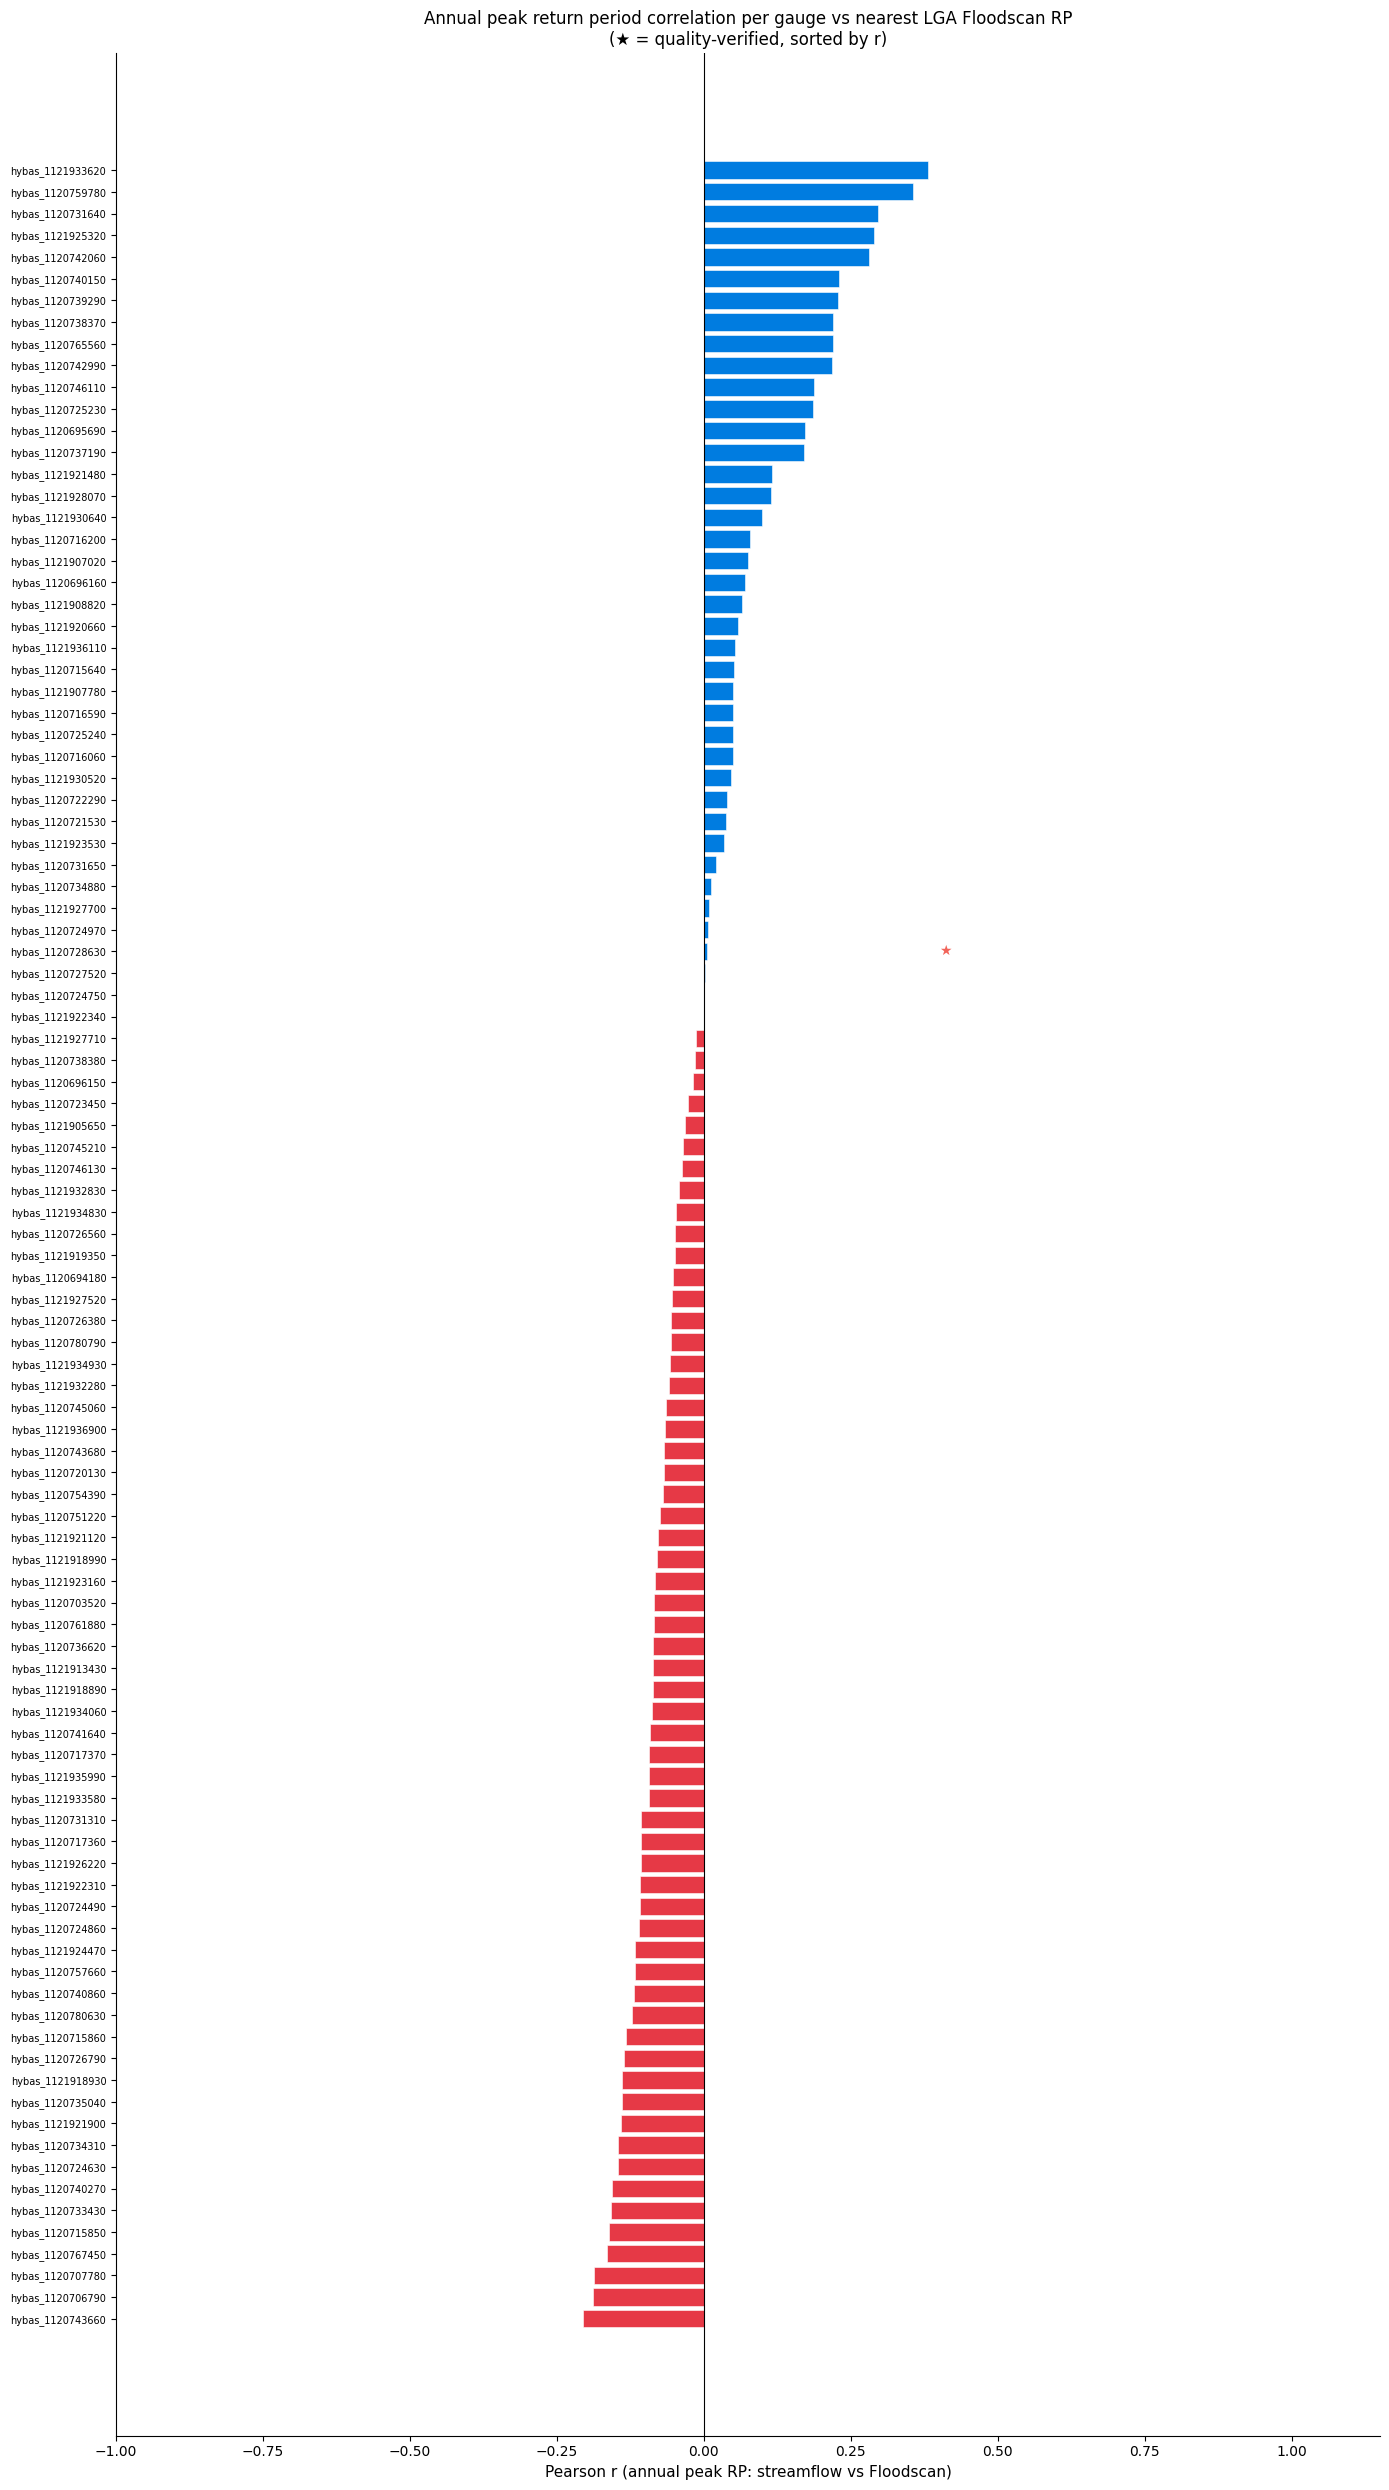

In [35]:
# --- Bar plot: RP correlation per gauge, sorted descending ---
fig, ax = plt.subplots(figsize=(14, max(6, len(df_gauge_rp) * 0.25)))

colors = ["#E63946" if r < 0 else "#007CE0" for r in df_gauge_rp["rp_r"]]
bars = ax.barh(
    range(len(df_gauge_rp)),
    df_gauge_rp["rp_r"],
    color=colors,
    edgecolor="white",
    linewidth=0.4,
)

# Star quality-verified gauges
for i, (_, row) in enumerate(df_gauge_rp.iterrows()):
    if row["quality_verified"]:
        ax.text(
            df_gauge_rp["rp_r"].max() + 0.02, i, "★",
            va="center", ha="left", fontsize=10, color="#F2645A",
        )

ax.set_yticks(range(len(df_gauge_rp)))
ax.set_yticklabels(df_gauge_rp["gauge_id"], fontsize=7)
ax.invert_yaxis()
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson r (annual peak RP: streamflow vs Floodscan)", fontsize=11)
ax.set_title(
    "Annual peak return period correlation per gauge vs nearest LGA Floodscan RP\n(★ = quality-verified, sorted by r)",
    fontsize=12,
)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(-1, 1.15)

plt.tight_layout()
plt.savefig("figures/gauge_rp_correlation_bar.png", dpi=200, bbox_inches="tight")

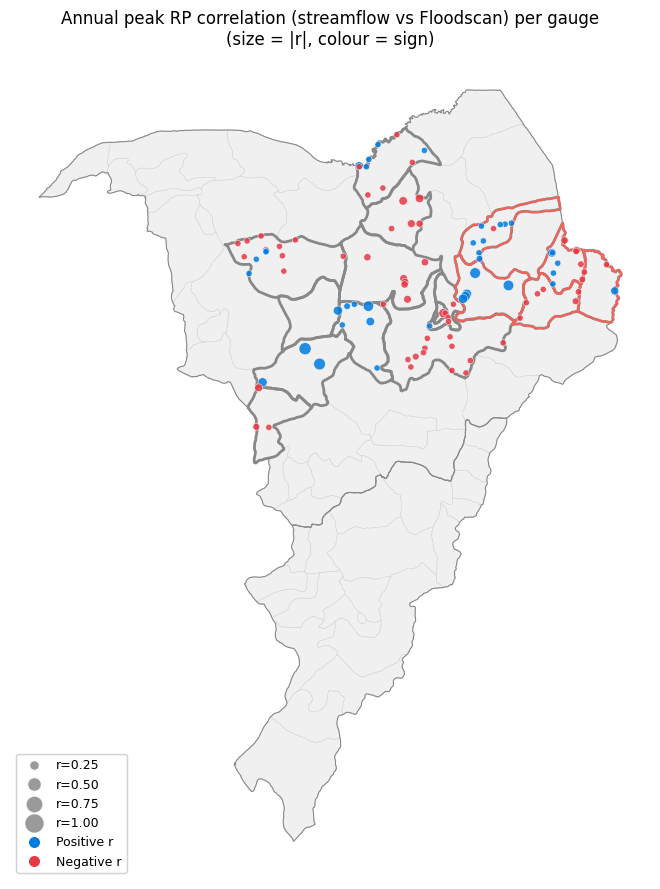

In [36]:
# --- Map: gauges coloured and sized by RP correlation ---
gdf_gauge_rp = gauges_with_model.merge(df_gauge_rp[["gauge_id", "rp_r"]], on="gauge_id", how="inner")

fig, ax = plt.subplots(figsize=(10, 9))

gdf_lga_states.plot(ax=ax, facecolor="#f0f0f0", edgecolor="#cccccc", linewidth=0.3)
gdf_adm1_states.plot(ax=ax, facecolor="none", edgecolor="#888888", linewidth=0.8)
gdf_lga_sel.plot(ax=ax, facecolor="none", edgecolor="#888888", linewidth=2.0, zorder=3)
gdf_focal.plot(ax=ax, facecolor="none", edgecolor="#F2645A", linewidth=1.5, zorder=4)

colors = ["#E63946" if r < 0 else "#007CE0" for r in gdf_gauge_rp["rp_r"]]
sizes = (gdf_gauge_rp["rp_r"].abs() * 200).clip(lower=20)

ax.scatter(
    gdf_gauge_rp.geometry.x,
    gdf_gauge_rp.geometry.y,
    c=colors,
    s=sizes,
    zorder=5,
    edgecolors="white",
    linewidths=0.4,
    alpha=0.85,
)

for r_val, label in [(0.25, "r=0.25"), (0.5, "r=0.50"), (0.75, "r=0.75"), (1.0, "r=1.00")]:
    ax.scatter([], [], c="#888888", s=r_val * 200, label=label, alpha=0.85, edgecolors="white")
ax.scatter([], [], c="#007CE0", s=80, label="Positive r", edgecolors="white")
ax.scatter([], [], c="#E63946", s=80, label="Negative r", edgecolors="white")

ax.legend(fontsize=9, loc="lower left", framealpha=0.9)
ax.set_title("Annual peak RP correlation (streamflow vs Floodscan) per gauge\n(size = |r|, colour = sign)", fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.savefig("figures/gauge_rp_correlation_map.png", dpi=200, bbox_inches="tight")